---

# <span style="color:#1F4E79;">Digital Ocean</span>
### <span style="color:#2E86AB;">Assignment 2:  CMEMS Data Handling</span>

---

### <span style="color:#4E8FD9;">Table of Contents</span>
- [Part 1: Download Data](#Part-1:-Download-Data)
- [Part 2: Data Investigation](#Part-2:-Data-Investigation)
- [Part 3: Variable Map Distribution](#Part-3:-Variable-Map-Distribution)
- [Part 4: Mean and Standard Deviation Maps of Variables](#Part-4:-Mean-and-Standard-Deviation-Maps-of-Variables)

###
---

In [11]:
# Import necessary libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import copernicusmarine
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Part 1: Download data

login: nslimak


password: SzybkieRybki123!

In [4]:
# copernicusmarine.subset(
#     dataset_id="cmems_mod_arc_phy_my_topaz4_P1M",
#     variables=["mlotst", "siconc", "sisnthick", "so", "thetao", "vxsi", "vysi"],
#     # minimum_longitude=-5.0,
#     # maximum_longitude=36.0,
#     # minimum_latitude=30.0,
#     # maximum_latitude=46.0,
#     start_datetime="2015-01-01T00:00:00",
#     end_datetime="2016-12-31T23:59:59",
#     output_directory="Data",
#     output_filename="cmems_arctic_2015-2016.nc",
#     force_download=True
# )

WARNING - 2026-03-17T12:43:55Z - 'force_download' has been deprecated.
INFO - 2026-03-17T12:43:55Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:Copernicus Marine password:

INFO - 2026-03-17T12:44:01Z - Selected dataset version: "202506"
INFO - 2026-03-17T12:44:01Z - Selected dataset part: "default"
100%|██████████| 151/151 [01:45<00:00,  1.44it/s]


ResponseSubset(file_path=WindowsPath('Data/cmems_arctic_2015-2016.nc'), output_directory=WindowsPath('Data'), filename='cmems_arctic_2015-2016.nc', file_size=23711.8664351145, data_transfer_size=7674.595419847328, variables=['mlotst', 'siconc', 'sisnthick', 'so', 'thetao', 'vxsi', 'vysi'], coordinates_extent=[GeographicalExtent(minimum=-180.0, maximum=179.875, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=50.0, maximum=90.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2015-01-01T00:00:00+00:00', maximum='2016-12-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.0, maximum=4000.0, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED')

# Part 2: Data Investigation

The geophysical fields in the dataset:
1. **mlotst:** Ocean mixed layer thickness [m]
2. **siconc:** Sea-ice concentration (fraction/percent of ocean area covered by ice) [%]
3. **sisnthick:** Snow thickness on sea ice [m]
4. **so:** Sea-water salinity (practical salinity or equivalent model salinity units)
5. **thetao:** Sea-water potential temperature [degK]
6. **vxsi:** Sea-ice velocity in x/eastward model direction [m/s]
7. **vysi:** Sea-ice velocity in y/northward model direction [m/s]

# Part 3: Variable Map Distribution

In [49]:
# Load the dataset
ds = xr.open_dataset("Data/cmems_arctic_2015-2016.nc")

# Extract a single time slice
sst_day_one = ds['mlotst'].isel(time=0) # time index 0 = time step in the dataset = January 1, 2015

# General function for plotting a variable map disturibution
def plot_variable_map(ds, variable, time_sel, cbar_label, title, depth_sel=None):
    """Plot a 2D map of a dataset variable for a selected date/time index."""

    # Select the variable and the time slice
    da = ds[variable]
    da_plot = da.sel(time=np.datetime64(time_sel), method='nearest')

    # Depth handling
    if 'depth' in da_plot.dims:
        if depth_sel is not None:
            da_plot = da_plot.isel(depth=depth_sel)
        else:
            da_plot = da_plot.isel(depth=0)  # Select the surface layer

    # Set up the plot
    plt.figure(figsize=(11,4))
    da_plot.plot(cmap='viridis', cbar_kwargs={'label': cbar_label if cbar_label else variable})

    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    return

### Ocean Mixed Layer Thickness (mlotst)

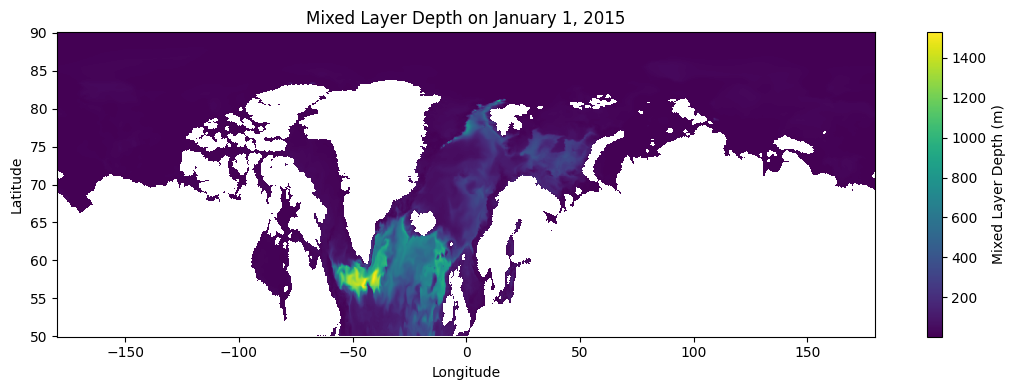

In [41]:
plot_variable_map( 
    ds,
    variable='mlotst',
    time_sel='2015-01-01',
    cbar_label='Mixed Layer Depth (m)',
    title='Mixed Layer Depth on January 1, 2015')

### Sea-ice Concentration (sicons)

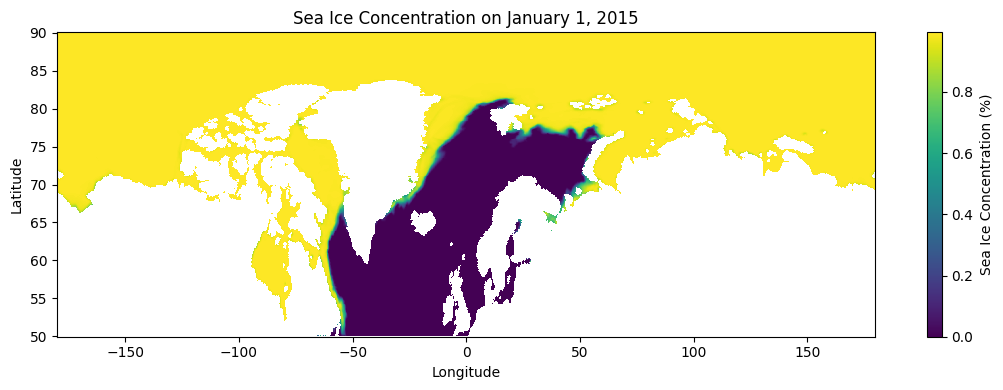

In [42]:
plot_variable_map( 
    ds,
    variable='siconc',
    time_sel='2015-01-01',
    cbar_label='Sea Ice Concentration (%)',
    title='Sea Ice Concentration on January 1, 2015'
)

### Sea Ice Thickness (sisnthick)

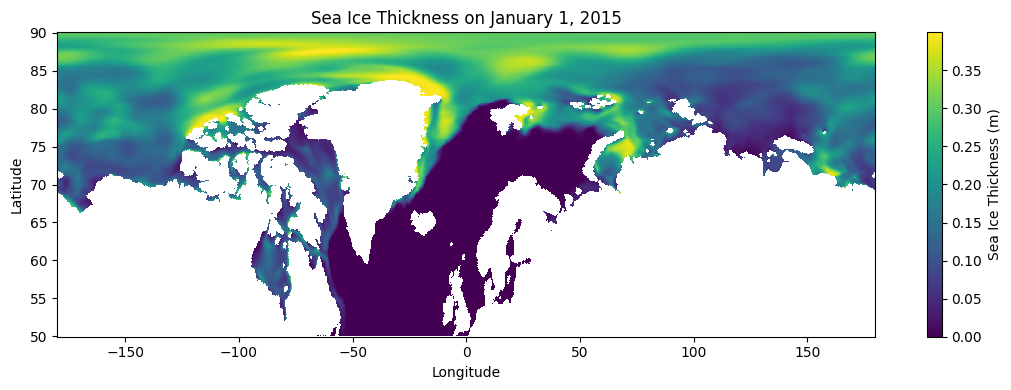

In [43]:
plot_variable_map( 
    ds,
    variable='sisnthick',
    time_sel='2015-01-01',
    cbar_label='Sea Ice Thickness (m)',
    title='Sea Ice Thickness on January 1, 2015'
)

### Sea-ice Velocity in x/Eastmodel Direction (vxsi)

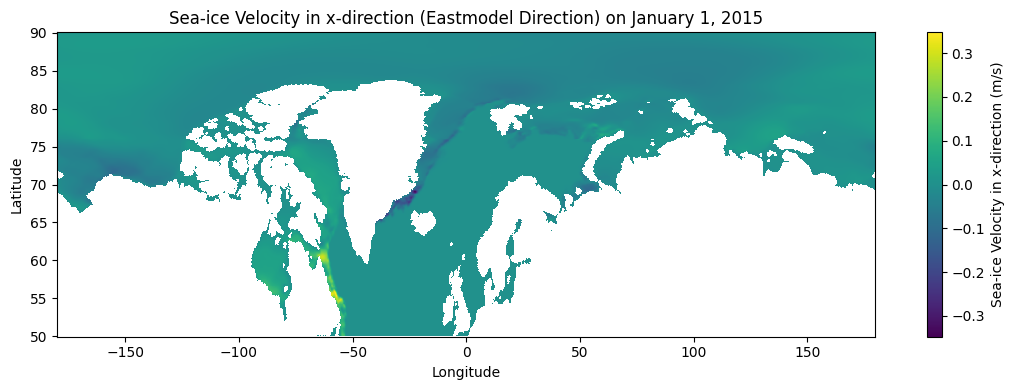

In [46]:
plot_variable_map( 
    ds,
    variable='vxsi',
    time_sel='2015-01-01',
    cbar_label='Sea-ice Velocity in x-direction (m/s)',
    title='Sea-ice Velocity in x-direction (Eastmodel Direction) on January 1, 2015'
)

### Sea-ice Velocity in y/Northmodel Direction (vysi)

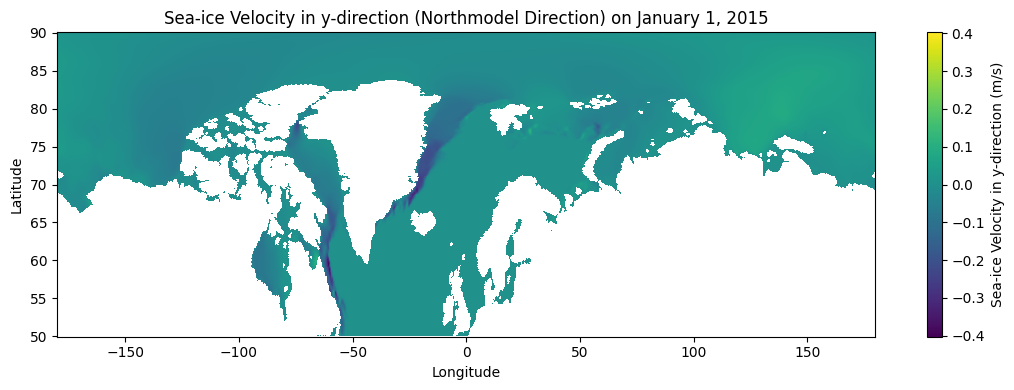

In [47]:
plot_variable_map( 
    ds,
    variable='vysi',
    time_sel='2015-01-01',
    cbar_label='Sea-ice Velocity in y-direction (m/s)',
    title='Sea-ice Velocity in y-direction (Northmodel Direction) on January 1, 2015'
)

### Sea-water Salinity (so)

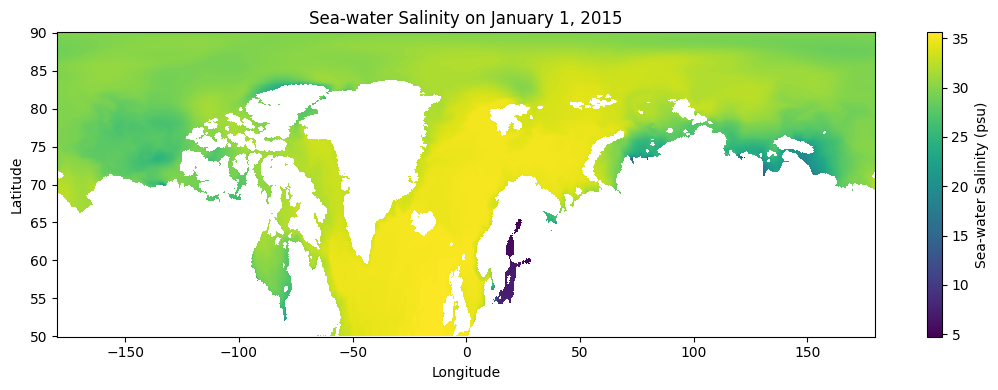

In [51]:
plot_variable_map( 
    ds,
    variable='so',
    time_sel='2015-01-01',
    cbar_label='Sea-water Salinity (psu)',
    title='Sea-water Salinity on January 1, 2015',
    depth_sel=0 # depth needs to be specified
)

### Sea-water Potential Temperature (thetao)

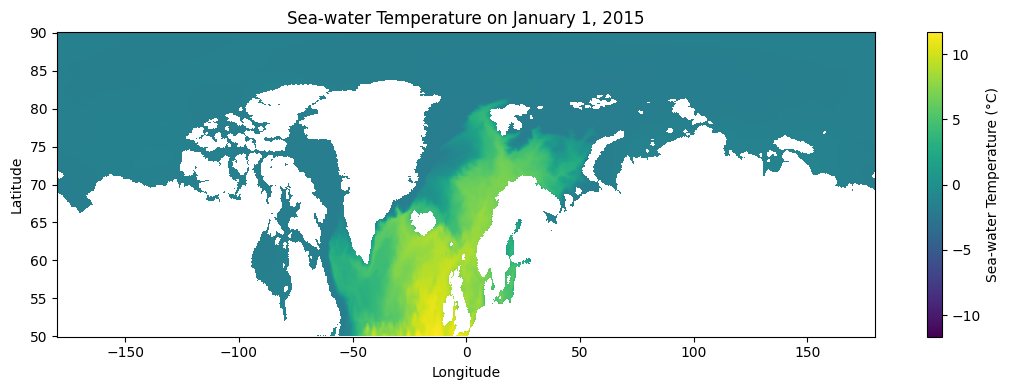

In [52]:
plot_variable_map( 
    ds,
    variable='thetao',
    time_sel='2015-01-01',
    cbar_label='Sea-water Temperature (°C)',
    title='Sea-water Temperature on January 1, 2015',
    depth_sel=0 # depth needs to be specified 
)

## <span style="color:#ED551A;">Takeaways!</span>
The **Sea-water Salinity** graph and **Sea-water Potential Temperature** graph depend on the `time`, `latitude`, `longitute` as the other variables but also on the `depth` therefore a specific value had to be picked insted of having a surface value analyzed. 

# Part 4: Mean and Standard Deviation Maps of Variables